# 03 Forecast Accuracy and Optimization

Forecast error is the difference between the observed value and the value predicted before seeing it:

$$e_t = y_t - \hat y_{t|t-1}.$$

Common accuracy measures are:

$$MAD = \frac{1}{n}\sum |e_t|,$$

$$MSE = \frac{1}{n}\sum e_t^2,$$

$$MAPE = \frac{100}{n}\sum \left|\frac{e_t}{y_t}\right|.$$

The lecture also emphasizes SSE when choosing smoothing constants. Smaller values are better when comparing models on the same response scale and evaluation window.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from checks import check_between, check_close, check_columns
from smoothing_utils import (
    accuracy_measures, initial_level_mean, initial_line,
    simple_es, optimize_simple_es,
    holt_trend, optimize_holt, holt_forecast_table,
    holt_winters, optimize_holt_winters, holt_winters_forecast,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)
DATA_DIR = Path('data')

In [3]:
cod = pd.read_csv(DATA_DIR / 'cod_catch.csv')
y = cod['CodCatch'].to_numpy()
l0 = initial_level_mean(y, n=12)

grid = []
for alpha in np.linspace(0, 1, 21):
    fit = simple_es(y, alpha=alpha, l0=l0)
    grid.append({'alpha': alpha, **accuracy_measures(y, fit['yhat_one_step'])})
grid = pd.DataFrame(grid)
grid.sort_values('SSE').head()

,alpha,SSE,MAD,MSE,MAPE
1,0.05,28137.8761,28.7021,1172.4115,8.5310
0,0.00,28424.3333,28.6806,1184.3472,8.5749
2,0.10,28735.1070,28.8536,1197.2961,8.5398
3,0.15,29677.8488,29.0667,1236.5770,8.5750
4,0.20,30771.7304,29.3232,1282.1554,8.6280


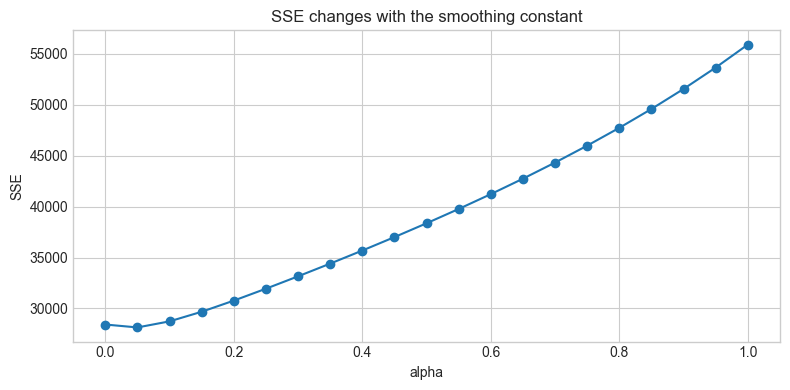

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid['alpha'], grid['SSE'], marker='o')
ax.set_xlabel('alpha')
ax.set_ylabel('SSE')
ax.set_title('SSE changes with the smoothing constant')
plt.tight_layout()

## In-Sample Fit vs. Forecast Use

Optimization usually minimizes one-step-ahead errors on the data used to fit the model. That is useful, but it is not the same as a guarantee of future performance. When enough data are available, it is helpful to reserve the last few observations as a test period.

In [5]:
train = y[:-6]
test = y[-6:]
l0_train = initial_level_mean(train, n=9)
alpha_train, train_fit, train_metrics = optimize_simple_es(train, l0=l0_train)
combined_fit = simple_es(y, alpha=alpha_train, l0=l0_train)
test_fitted = combined_fit['yhat_one_step'].iloc[-6:].to_numpy()
test_metrics = accuracy_measures(test, test_fitted)

print(f'Alpha chosen on training data: {alpha_train:.4f}')
pd.DataFrame({'training_one_step': train_metrics, 'test_one_step': test_metrics})

Alpha chosen on training data: 0.0093


,training_one_step,test_one_step
SSE,25859.3314,3404.2805
MAD,32.4060,18.4356
MSE,1436.6295,567.3801
MAPE,9.7129,5.5849


## How to Use Accuracy Measures

Use accuracy measures to compare reasonable models, not to replace judgment. For example, a trend model should not be rejected only because simple smoothing barely wins in-sample by SSE; if the plot clearly shows trend, a level-only model may forecast poorly when the trend continues.